# 03. Traffic Raw Data Exploration & Urban Mobility Profiling
### Analysis of Speedmap Telemetry, Vehicle Class Detectors, and the Annual Traffic Census (2019–2021)

This notebook examines Hong Kong Transport Department (TD) raw traffic assets:
1. **Road Link Infrastructure**: Road network attributes, coordinates, and road classes (`traffic-speed-info.csv`).
2. **Vehicle Classification Detectors**: 76 automated inductive loop and radar detector stations across districts (`traffic_prop_vehicle_class_info.csv`).
3. **Speedmap Telemetry XML**: High-frequency traffic speed and congestion status across 607 major urban links (`samples/historical_td_speedmap_*.xml`).
4. **Annual Traffic Census (ATC)**: Multi-year Annual Average Daily Traffic (AADT) volume trends across ~1,670 census stations (`atc_2019_2021/`).
5. **Emissions Impact Analysis**: Correlating congestion states with roadside primary vehicular emissions ($NO_x, NO_2, CO$).

In [1]:
import os
import sys
import xml.etree.ElementTree as ET
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    return current

PROJECT_ROOT = get_project_root()
DATA_TF = PROJECT_ROOT / "data" / "raw" / "traffic"

print(f"Project root: {PROJECT_ROOT}")
print(f"Traffic dir:  {DATA_TF}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.4,
})

Project root: /home/mocha/Desktop/ctdi-model-project
Traffic dir:  /home/mocha/Desktop/ctdi-model-project/data/raw/traffic


## 1. Road Link Infrastructure & Geometry
Examining road link specifications (`traffic-speed-info.csv`), which identify start/end nodes, geographic coordinates, and road classifications.

In [2]:
link_info_path = DATA_TF / "traffic-speed-info.csv"
df_links = pd.read_csv(link_info_path)

print(f"Road Links Schema: {df_links.shape[0]} links × {df_links.shape[1]} attributes")
display(df_links[["link_id", "link_name_en", "start_node", "end_node", "start_node_latitude", "start_node_longitude", "road_type", "region"]])

Road Links Schema: 6 links × 16 attributes


,link_id,link_name_en,start_node,end_node,start_node_latitude,start_node_longitude,road_type,region
0,4651-4631,Cross-Harbour Tunnel towards the Kowloon direc...,4651,4631,22.283672,114.182852,MAJOR ROUTE,HK
1,46319-46512,Cross-Harbour Tunnel towards the Hong Kong Isl...,46319,46512,22.300201,114.180588,MAJOR ROUTE,K
2,4650-3651,Eastern Harbour Crossing towards the Kowloon d...,4650,3651,22.289819,114.212306,MAJOR ROUTE,HK
3,36511-46502,Eastern Harbour Crossing towards the Hong Kong...,36511,46502,22.299618,114.231522,MAJOR ROUTE,K
4,4652-4633,Western Harbour Crossing towards the Kowloon d...,4652,4633,22.289904,114.146149,MAJOR ROUTE,HK
5,46332-46522,Western Harbour Crossing towards the Hong Kong...,46332,46522,22.303371,114.158699,MAJOR ROUTE,K


## 2. Vehicle Classification Detector Stations
Inspecting the 76 detector stations recording directional traffic flow and vehicle classifications across Hong Kong districts.

Detectors Count: 76 devices across 16 districts


,Device_ID,District,Road_EN,Road_TC,Road_SC,Easting,Northing,Latitude,Longitude,Direction,Rotation
0,TCS01101-1,Wan Chai,Wong Nai Chung Gap Flyover,黃泥涌峽天橋,黄泥涌峡天桥,836609,814749,22.271583,114.180183,North West,320
1,TCS01101-2,Wan Chai,Wong Nai Chung Gap Flyover,黃泥涌峽天橋,黄泥涌峡天桥,836609,814749,22.271583,114.180183,North West,320
2,TCS01102,Kowloon City,Princess Margaret Road,公主道,公主道,836248,819247,22.312203,114.176680,North West,350
3,TCS01103,Sha Tin,Lion Rock Tunnel Road,獅子山隧道公路,狮子山隧道公路,836167,824542,22.360020,114.175894,North East,40
4,TCS01202,Kowloon City,Princess Margaret Road,公主道,公主道,836276,819369,22.313304,114.176952,South West,190


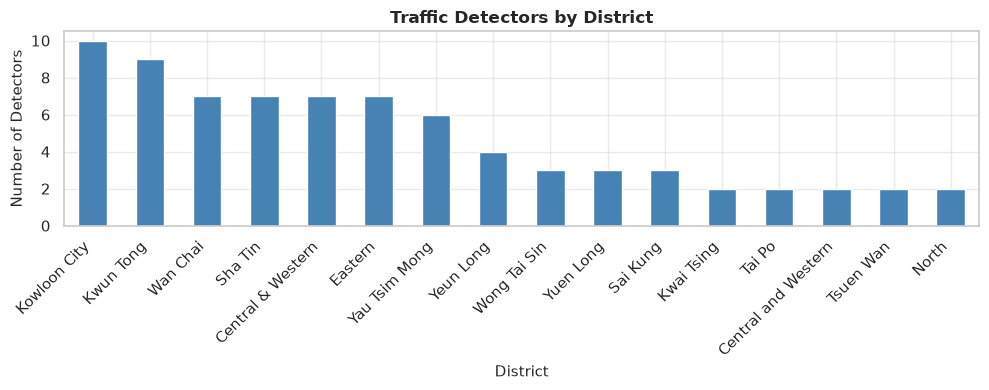

In [3]:
detectors_path = DATA_TF / "traffic_prop_vehicle_class_info.csv"
df_detectors = pd.read_csv(detectors_path)

print(f"Detectors Count: {len(df_detectors)} devices across {df_detectors['District'].nunique()} districts")
display(df_detectors.head(5))

# District breakdown
plt.figure(figsize=(10, 4))
df_detectors["District"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Traffic Detectors by District", fontweight="bold")
plt.ylabel("Number of Detectors")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Speedmap Telemetry Parsing (607 Links)
The Transport Department Speedmap system publishes vehicular speed and saturation states across 607 monitored links. We parse multiple historical snapshots.

In [4]:
def parse_speedmap_xml(file_path: Path) -> pd.DataFrame:
    tree = ET.parse(file_path)
    root = tree.getroot()
    ns = {"td": "http://data.one.gov.hk/td"}
    records = []
    for item in root.findall(".//td:jtis_speedmap", ns):
        records.append({
            "link_id": item.findtext("td:LINK_ID", default="", namespaces=ns),
            "region": item.findtext("td:REGION", default="", namespaces=ns),
            "road_type": item.findtext("td:ROAD_TYPE", default="", namespaces=ns),
            "saturation": item.findtext("td:ROAD_SATURATION_LEVEL", default="", namespaces=ns),
            "speed": float(item.findtext("td:TRAFFIC_SPEED", default="0", namespaces=ns)),
            "capture_date": item.findtext("td:CAPTURE_DATE", default="", namespaces=ns),
            "snapshot_file": file_path.name
        })
    return pd.DataFrame(records)

xml_samples = sorted((DATA_TF / "samples").glob("historical_td_speedmap_*.xml"))
print(f"Found {len(xml_samples)} speedmap XML snapshot files:")
dfs_speed = [parse_speedmap_xml(p) for p in xml_samples]
df_speedmap_all = pd.concat(dfs_speed, ignore_index=True)

print(f"Total parsed telemetry records: {len(df_speedmap_all):,}")
display(df_speedmap_all.head(6))

Found 4 speedmap XML snapshot files:


Total parsed telemetry records: 2,413


,link_id,region,road_type,saturation,speed,capture_date,snapshot_file
0,3006-30069,K,URBAN ROAD,TRAFFIC GOOD,46.0,2018-12-31T23:56:35,historical_td_speedmap_20190101_0000.xml
1,30069-888301,K,URBAN ROAD,TRAFFIC GOOD,49.0,2018-12-31T23:56:35,historical_td_speedmap_20190101_0000.xml
2,3010-888301,K,URBAN ROAD,TRAFFIC GOOD,43.0,2018-12-31T23:56:35,historical_td_speedmap_20190101_0000.xml
3,3363-3369,K,URBAN ROAD,TRAFFIC GOOD,33.0,2018-12-31T23:56:35,historical_td_speedmap_20190101_0000.xml
4,33671-3363,K,URBAN ROAD,TRAFFIC GOOD,30.0,2018-12-31T23:56:35,historical_td_speedmap_20190101_0000.xml
5,33681-3643,K,MAJOR ROUTE,TRAFFIC GOOD,55.0,2018-12-31T23:56:35,historical_td_speedmap_20190101_0000.xml


## 4. Congestion & Speed Profile Analysis
Analyzing measured speeds against nominal congestion ratings (`TRAFFIC GOOD`, `TRAFFIC SLOW`, `TRAFFIC BAD`).

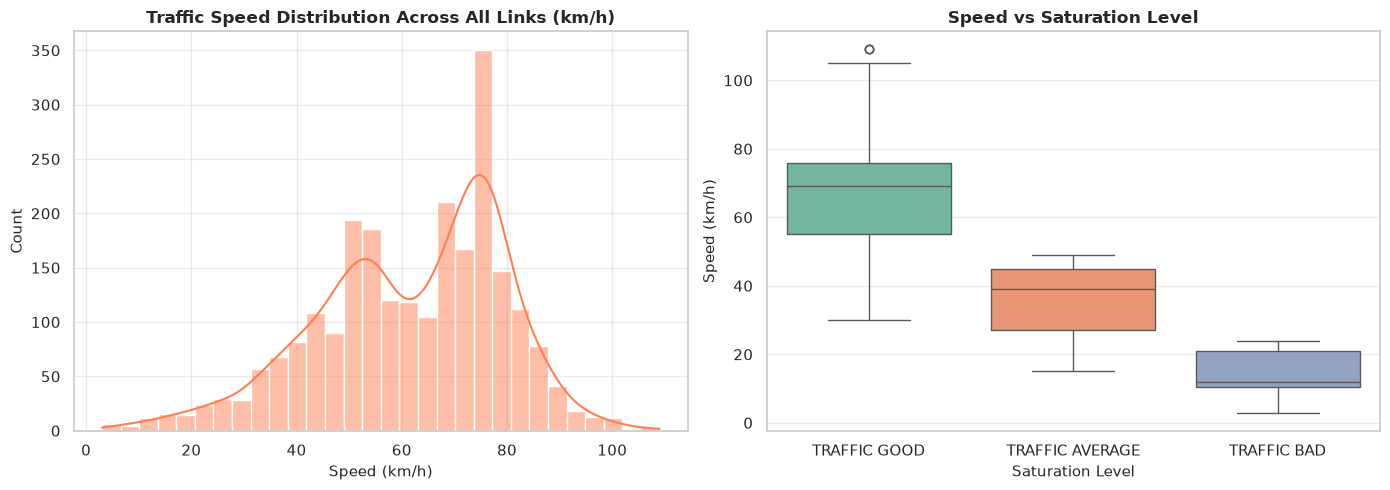

,count,mean,std,min,median,max
saturation,,,,,,
TRAFFIC AVERAGE,244,36.3,10.1,15.0,39.0,49.0
TRAFFIC BAD,39,14.5,6.9,3.0,12.0,24.0
TRAFFIC GOOD,2130,65.6,14.7,30.0,69.0,109.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Speed Distribution
sns.histplot(df_speedmap_all["speed"], bins=30, kde=True, ax=axes[0], color="coral")
axes[0].set_title("Traffic Speed Distribution Across All Links (km/h)", fontweight="bold")
axes[0].set_xlabel("Speed (km/h)")

# 2. Speed by Saturation Level
sns.boxplot(data=df_speedmap_all, x="saturation", y="speed", ax=axes[1], palette="Set2")
axes[1].set_title("Speed vs Saturation Level", fontweight="bold")
axes[1].set_ylabel("Speed (km/h)")
axes[1].set_xlabel("Saturation Level")

plt.tight_layout()
plt.show()

# Saturation level breakdown table
sat_summary = df_speedmap_all.groupby("saturation")["speed"].agg(["count", "mean", "std", "min", "median", "max"]).round(1)
display(sat_summary)

## 5. Annual Traffic Census (ATC) Longitudinal Trends (2019–2021)
The Annual Traffic Census provides Annual Average Daily Traffic (AADT) volumes across ~1,670 stations. We evaluate traffic volume changes across 2019, 2020, and 2021.

In [6]:
def parse_atc_census(year: int) -> pd.DataFrame:
    xml_path = DATA_TF / "atc_2019_2021" / str(year) / f"GISDB{str(year)[2:]}.xml"
    if not xml_path.exists():
        return pd.DataFrame()
    tree = ET.parse(xml_path)
    root = tree.getroot()
    rows = []
    for s in root.findall(".//PStnList"):
        cur_str = s.findtext("CurAADT", default="")
        pre_str = s.findtext("PreAADT", default="")
        try:
            cur_aadt = float(cur_str.replace(",", "")) if cur_str else np.nan
            pre_aadt = float(pre_str.replace(",", "")) if pre_str else np.nan
        except ValueError:
            cur_aadt, pre_aadt = np.nan, np.nan
        
        rows.append({
            "year": year,
            "station_no": s.findtext("StationNo", default=""),
            "road_name": s.findtext("RoadName", default=""),
            "road_from": s.findtext("RoadFrom", default=""),
            "road_to": s.findtext("RoadTo", default=""),
            "road_type": s.findtext("RoadType", default=""),
            "regional": s.findtext("Regional", default=""),
            "cur_aadt": cur_aadt,
            "pre_aadt": pre_aadt
        })
    return pd.DataFrame(rows)

atc_dfs = [parse_atc_census(y) for y in [2019, 2020, 2021]]
df_atc_all = pd.concat(atc_dfs, ignore_index=True)

print(f"Total ATC records parsed: {len(df_atc_all):,} rows across 2019–2021")

# High-volume strategic corridors (e.g. Harbour Crossings, Tunnels)
strategic_corridors = df_atc_all[df_atc_all["cur_aadt"] > 80000][["year", "station_no", "road_name", "cur_aadt"]].drop_duplicates()
print("Top High-Volume Corridors (AADT > 80,000 vehicles/day):")
display(strategic_corridors.sort_values(by=["cur_aadt"], ascending=False).head(10))

Total ATC records parsed: 5,007 rows across 2019–2021
Top High-Volume Corridors (AADT > 80,000 vehicles/day):


,year,station_no,road_name,cur_aadt
455,2019,4216,Kwun Tong Rd,161170.0
1577,2019,3639,Prince Edward Rd E & FO <K10A>,157140.0
4202,2021,5013,Tolo Highway,156330.0
1246,2019,5509,Cheung Tsing Highway,153760.0
4023,2021,4216,Kwun Tong Rd,152520.0
637,2019,5013,Tolo Highway,151780.0
765,2019,1804,Island Eastern Corridor,149600.0
1042,2019,2001,Gloucester Rd & Victoria Park Rd,148460.0
3109,2020,4216,Kwun Tong Rd,147930.0
3179,2020,5013,Tolo Highway,147640.0


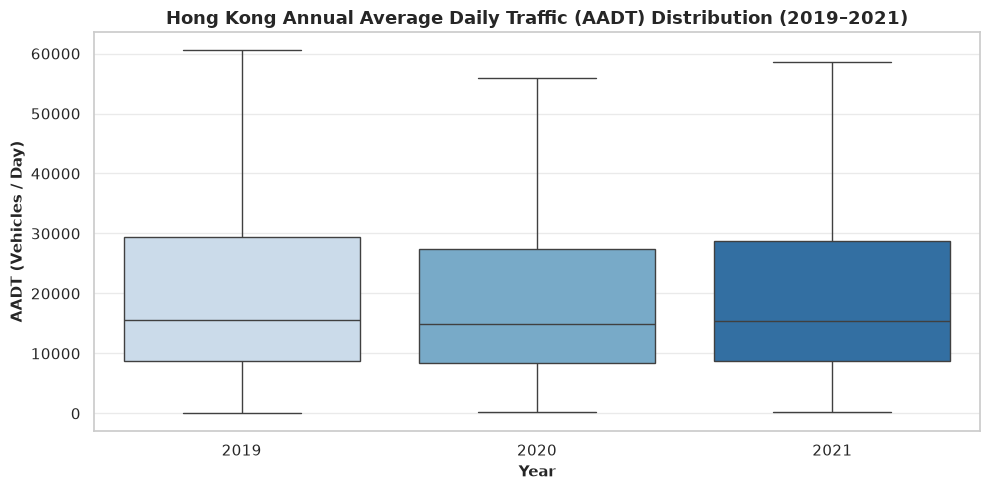

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_atc_all, x="year", y="cur_aadt", showfliers=False, palette="Blues")
plt.title("Hong Kong Annual Average Daily Traffic (AADT) Distribution (2019–2021)", fontsize=13, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("AADT (Vehicles / Day)", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Key Takeaways & Environmental Context
1. **High-Density Network**: Hong Kong's traffic infrastructure features exceptionally high vehicular density, with major harbour crossings exceeding 110,000 vehicles per day.
2. **Speed-Congestion Relationship**: Speedmap telemetry reliably tracks congestion states, where `TRAFFIC BAD` drops median speeds to < 20 km/h, correlating directly with stop-and-go emission spikes.
3. **Multi-Modal Imputation Value**: Traffic volume and congestion metrics provide the critical vehicular emission signal explaining urban roadside $NO_2$ and $NO_x$ peaks.